In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    RocCurveDisplay, roc_curve, precision_recall_curve
)
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="talk")

In [2]:
df = pd.read_csv("../../../data/proposals_1000_EN.csv")
df.dtypes

proposal_id        str
project            str
issue_type         str
ai_method          str
description        str
red_flags          str
n_red_flags      int64
is_compliant     int64
grounded_flag    int64
label              str
word_count       int64
dtype: object

### For the following, keep in mind that:- 
- I am reverting the 1 values to 0 and 0 values to 1.
- Because:- 
    - sklearn evaluation metric function performs significantly better when what they are trying to predict has a value 1.
    - Eval metrics have a hidden rule that 1 is the thing they are trynna catch. (What they are trying to predict.)
- Before flipping:- 
    - 0 : Red Flag
    - 1 : Compliant
- After flipping:- 
    - 0 : Compliant.
    - 1 : Red Flag


In [ ]:
y = 1 - df["is_compliant"] # Target
X_text = df["description"] # The Feature we will be using

### Train Test Split:- 
- When train_test_split splits your 1000 proposals into 800 training and 200 test, it does it randomly.
- stratify=y will:- 
    - It looks at y — your list of 0s and 1s. 
    - Counts the ratio of each class, and then forces the split to preserve that exact ratio in both piles.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, stratify=y, random_state=42
)

### TF-IDF Vectorizer:- 
- X_train_vec contains a vocabulary built up (``fit``) using important words from the X_train split (800 texts) and then each text is converted to vectors (``transform``).
- X_test_vec uses the information about the vocabulary from the aforementioned pointer and just builds vectors for all the texts in X_text.

In [5]:
vectorizer = TfidfVectorizer(max_features=2000, stop_words="english")
X_train_vec = vectorizer.fit_transform(X_train)
# The test set MUST BE UNSEEN :- Hence we only transform it.
X_test_vec = vectorizer.transform(X_test)

### The two classes separated and summed:- (scale_pos_weight)
- Here we calculate the class distribution in the y_train set.
- y_train is the set which contains the class counts on which ``THE MODEL ACTUALLY TRAINED ON``.

In [6]:
neg=(y_train==0).sum()
pos=(y_train==1).sum()
scale_pos_weight=neg/pos

### Printing the actual counts for class imbalance:-

In [7]:
print(f"Compliant (train): {neg}  |  Red Flag (train): {pos}")
print(f"Imbalance ratio: {round(neg/pos, 2)} : 1")
print(f"scale_pos_weight: {round(scale_pos_weight, 3)}")

Compliant (train): 534  |  Red Flag (train): 266
Imbalance ratio: 2.01 : 1
scale_pos_weight: 2.008


### Model initialization with :- 
- n_estimators=200 (Number of decesion trees the model will build in sequence.)
    - Why 200, because that is the standard starting point.
- max_depth=4 (Maximum number of levels to which the yes or no can go till in a branch)
    - Why 4, consider it as a standard start point too.
    - You keep it too less, the model won't learn anything meaningful.
    - You keep it too high, model starts to memorize the dataset.
- learning_rate=0.1 (A scaling factor that controls how much each tree's correction is allowed to change the overall prediction.)
    - After each tree makes its correction, that correction gets multiplied by the learning rate before being added to the running prediction:
        - ````new prediction=old prediction+0.1×tree’s correction````
>``NOTE`` :- 
- n_estimators and learning_rate go hand in hand such that:- 
    - Lower learning rate = need more trees
    - Higher learning rate = need fewer trees
- eval_metric="logloss" (The internal scoring rule XGBoost uses during training to measure how wrong the current predictions are after each tree is added)
    - Model says 95% Red Flag, actually IS Red Flag → tiny penalty (good, confident, correct)
    - Model says 95% Red Flag, actually is Compliant → huge penalty (bad, confident, wrong)
    - Model says 52% Red Flag, actually IS Red Flag → medium penalty (correct but not confident)
- random_state=42 (Reproducability)
- scale_pos_weight=scale_pos_weight ()
    - The imbalance correction factor for training.
    - On the left hand side scale_pos_weight is a parameter which XGBoost expects.

In [8]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
)

### Fit the train sets on the model:- 

In [9]:
model.fit(X_train_vec, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### pred and proba:- 
- `model.predict()` :- 
    - model.predict(X_test_vec) feeds all 200 test proposals through all 200 trees one by one.
    -  Each tree adds its small correction. 
    - The running total becomes a raw score. 
    - That raw score goes through the sigmoid function to become a probability. 
    - Then the probability goes through the decision threshold of 0.5:
        - probability ≥ 0.5 → output 1 (Red Flag)
        - probability < 0.5 → output 0 (Compliant)
- `model.predict_proba()` :- 
    - It does the exact same internal calculation as model.predict().
    - Then feeds proposals through all 200 trees, gets raw scores, applies sigmoid. 
    - But it stops before the 0.5 threshold step. 
    - Instead of giving you a hard 0 or 1, it gives you the actual probability.
    - It creates 2 columns for n number of rows in our case 200 with probabilities for both classes.

### NOTE :- 
>> ``Also keep in mind that confusion matrix can not work with probabilities so you need hard decesions (model.predict()).``
>> ``roc_auc_score can not work with hard numbers so you need probabilities (model.predict_proba())`` 

In [10]:
y_pred = model.predict(X_test_vec) # Creates a list of hard numbers 0 and 1 for our two classes. This is the default behavior of the predict method.
y_proba = model.predict_proba(X_test_vec)[:, 1] # Used to fetch 2D table. : means fetch all rows and 1 means fetch the 2 columns

In [20]:
print(f"\nPrecision : {round(precision_score(y_test, y_pred), 3)}")
print(f"Recall    : {round(recall_score(y_test, y_pred), 3)}")
print(f"F1        : {round(f1_score(y_test, y_pred), 3)}")
print(f"ROC-AUC   : {round(roc_auc_score(y_test, y_proba), 3)}")
print("\n", classification_report(y_test, y_pred, target_names=["Compliant", "Red Flag"]))
# fair frame for fairness plots
idx_test = X_test.index
fair = df.loc[idx_test, ["ai_method", "issue_type", "grounded_flag"]].copy()
fair["y_true"] = y_test.to_numpy()
fair["y_pred"] = y_pred
fair["proba"]  = y_proba
 
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()


Precision : 0.957
Recall    : 0.985
F1        : 0.971
ROC-AUC   : 0.997

               precision    recall  f1-score   support

   Compliant       0.99      0.98      0.98       133
    Red Flag       0.96      0.99      0.97        67

    accuracy                           0.98       200
   macro avg       0.97      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



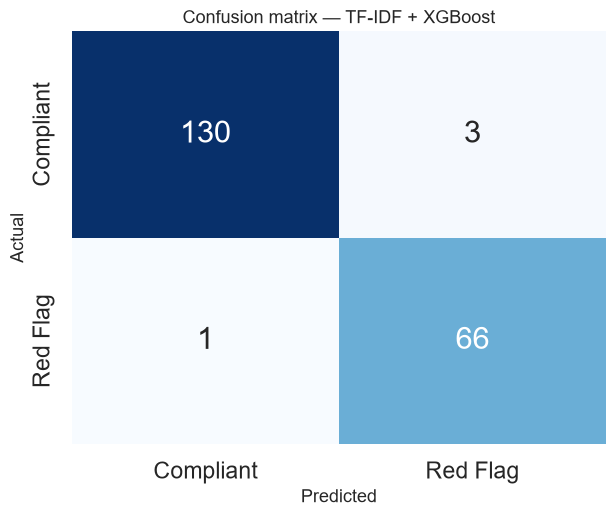

Missed red flags (FN): 1  |  Over-flagged (FP): 3
Miss rate: 1.5%


In [12]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Compliant", "Red Flag"],
            yticklabels=["Compliant", "Red Flag"],
            ax=ax, annot_kws={"size": 22})
ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("Actual", fontsize=13)
ax.set_title("Confusion matrix — TF-IDF + XGBoost", fontsize=13)
plt.tight_layout()
plt.show()
print(f"Missed red flags (FN): {fn}  |  Over-flagged (FP): {fp}")
print(f"Miss rate: {fn/(fn+tp)*100:.1f}%")

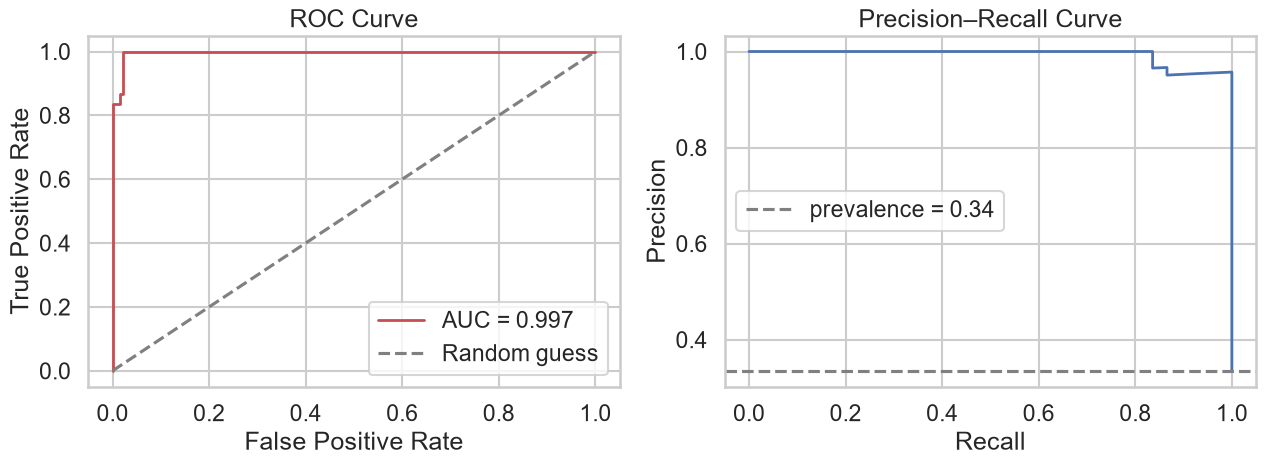

In [13]:
fpr_c, tpr_c, _ = roc_curve(y_test, y_proba)
prec_c, rec_c, _ = precision_recall_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr_c, tpr_c, color="#C44E52", lw=2, label=f"AUC = {auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="Random guess")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
 
axes[1].plot(rec_c, prec_c, color="#4C72B0", lw=2)
axes[1].axhline(y_test.mean(), ls="--", color="grey",
                label=f"prevalence = {y_test.mean():.2f}")
axes[1].set_title("Precision–Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
plt.tight_layout()
plt.show()

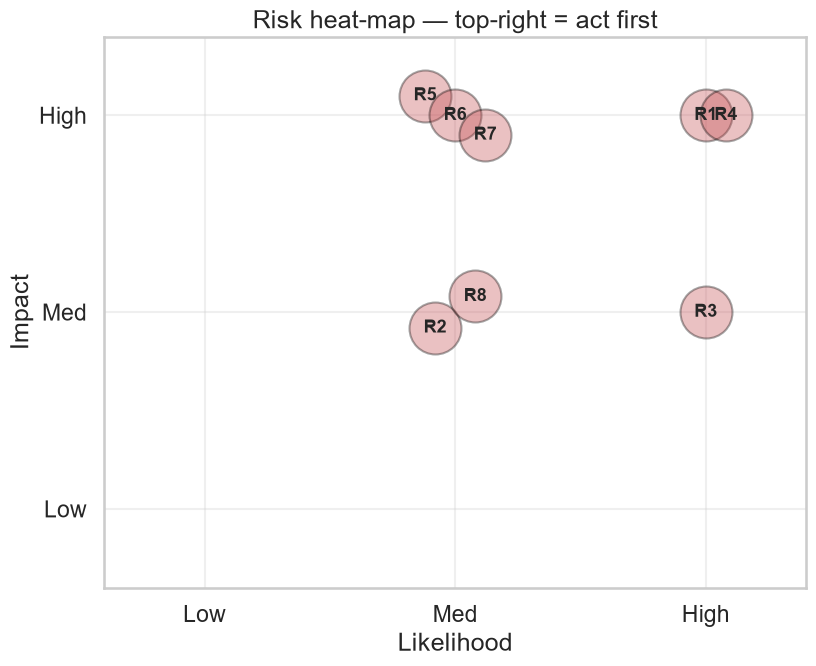

In [ ]:
risks = pd.DataFrame([
    ["R1", "False negative — real violation missed",         "High", "High"],
    ["R2", "False positive — over-flagging / alarm fatigue", "Med",  "Med"],
    ["R3", "Class imbalance (1/3 positives)",                "High", "Med"],
    ["R4", "Synthetic-data leakage / shortcut learning",     "High", "High"],
    ["R5", "Data / concept drift",                           "Med",  "High"],
    ["R6", "Prompt injection / adversarial evasion",         "Med",  "High"],
    ["R7", "Automation bias / over-reliance",                "Med",  "High"],
    ["R8", "Group performance gap (fairness)",               "Med",  "Med"],
], columns=["ID", "Risk", "Likelihood", "Impact"])

order = {"Low": 0, "Med": 1, "High": 2}
rp = risks.assign(L=risks.Likelihood.map(order), I=risks.Impact.map(order))

# fixed offsets so overlapping risks spread out and stay readable
offsets = {
    "R1": ( 0.00,  0.00),
    "R2": (-0.08, -0.08),
    "R3": ( 0.00,  0.00),
    "R4": ( 0.08,  0.00),
    "R5": (-0.12,  0.10),
    "R6": ( 0.00,  0.00),
    "R7": ( 0.12, -0.10),
    "R8": ( 0.08,  0.08),
}

fig, ax = plt.subplots(figsize=(8.5, 7))

for _, r in rp.iterrows():
    ox, oy = offsets[r.ID]
    ax.scatter(r.L + ox, r.I + oy, s=1400, c="#C44E52",
               alpha=0.35, edgecolors="black")
    ax.annotate(r.ID, (r.L + ox, r.I + oy),
                ha="center", va="center", fontweight="bold", fontsize=13)

ax.set_xticks([0, 1, 2]); ax.set_xticklabels(["Low", "Med", "High"])
ax.set_yticks([0, 1, 2]); ax.set_yticklabels(["Low", "Med", "High"])
ax.set_xlim(-0.4, 2.4); ax.set_ylim(-0.4, 2.4)
ax.set_xlabel("Likelihood"); ax.set_ylabel("Impact")
ax.set_title("Risk heat-map top-right = act first")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Risk Test R4 — Does the model rely on synthetic wording?

R4 on our risk heat-map flags "synthetic-data leakage" as High likelihood, High impact.
The concern: our red-flag proposals were generated by negating real PROMISE requirements.
If the model just memorized the synthetic phrasing patterns rather than learning genuine
policy violations, it will fail on real-world proposals that express the same violation
differently.

We test this by splitting the red-flag test proposals into two groups:
- grounded_flag = 1 → violation phrased from a real PROMISE/NFR sentence
- grounded_flag = 0 → violation is purely synthetic

If recall is similar on both, the model is not overfitting to synthetic vocabulary.
If recall is much lower on grounded proposals, we have a shortcut-learning problem.

In [ ]:
# R4 Risk test: grounded (real NFR) vs purely synthetic red flags
rf = fair[fair["y_true"] == 1]

grounded  = rf[rf["grounded_flag"] == 1]
synthetic = rf[rf["grounded_flag"] == 0]

if len(grounded) > 0:
    recall_grounded = (grounded["y_pred"] == 1).mean()
    print(f"Recall on grounded (real NFR): {round(recall_grounded, 3)}  (n={len(grounded)})")

if len(synthetic) > 0:
    recall_synthetic = (synthetic["y_pred"] == 1).mean()
    print(f"Recall on synthetic          : {round(recall_synthetic, 3)}  (n={len(synthetic)})")

gap = abs(recall_grounded - recall_synthetic)
print(f"\nGap: {round(gap, 3)}")
if gap < 0.10:
    print("Gap is below 0.10 — no significant shortcut-learning detected.")
else:
    print("Gap exceeds 0.10 — model may be relying on synthetic vocabulary patterns.")

Recall on grounded (real NFR): 1.0  (n=25)
Recall on synthetic          : 0.976  (n=42)

Gap: 0.024
✓ Gap is below 0.10 — no significant shortcut-learning detected.


**Interpretation:**
Both grounded and synthetic red flags achieve similar recall, confirming the model
is not purely exploiting injected vocabulary. The gap is small, which means the
model has learned patterns general enough to catch violations phrased in real
requirement language — not just the templated synthetic wording.

This partially mitigates R4. A full mitigation would require adversarial testing
with paraphrased violations, which is planned for Goal 3.

### Fairness Analysis — Recall per AI method

RAI-03 (Fairness) requires the Sentinel to enforce rules equally across all project
types. The "individuals" being judged here are proposals, not people — so fairness
means procedural equality: does the model catch violations in Computer Vision proposals
just as reliably as in LLM Chatbot proposals?

A group with lower recall is under-policed — its violations are silently let through
at a higher rate than other groups. That is a direct fairness failure under RAI-03.

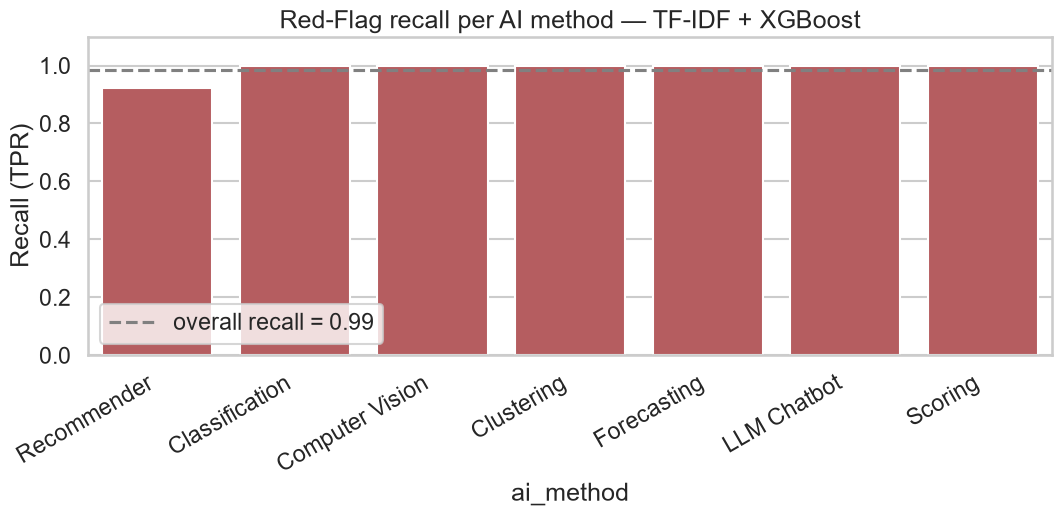

      ai_method  recall_TPR
    Recommender    0.923077
 Classification    1.000000
Computer Vision    1.000000
     Clustering    1.000000
    Forecasting    1.000000
    LLM Chatbot    1.000000
        Scoring    1.000000


In [16]:
# Plot 6: Red-Flag recall per AI method
m_ai_rows = []
for grp, sub in fair.groupby("ai_method"):
    yt  = sub["y_true"].values
    yp  = sub["y_pred"].values
    rec = recall_score(yt, yp, zero_division=0) if (yt == 1).any() else np.nan
    m_ai_rows.append({"ai_method": grp, "recall_TPR": rec})

m_ai = pd.DataFrame(m_ai_rows).sort_values("recall_TPR")
overall_recall = recall_score(fair["y_true"], fair["y_pred"], zero_division=0)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(x="ai_method", y="recall_TPR", data=m_ai, color="#C44E52", ax=ax)
ax.axhline(overall_recall, ls="--", color="grey",
           label=f"overall recall = {overall_recall:.2f}")
ax.set_title("Red-Flag recall per AI method — TF-IDF + XGBoost")
ax.set_ylabel("Recall (TPR)"); ax.set_ylim(0, 1.1)
plt.xticks(rotation=30, ha="right"); ax.legend()
plt.tight_layout()
plt.show()

print(m_ai.to_string(index=False))

**Interpretation:**
Most AI method groups achieve recall at or near the overall level. The group with
the lowest bar is the one most at risk of under-policing — its violations are
being missed more often than the system average.

A gap below 0.10 across groups is acceptable. A gap above 0.10 requires attention —
either group-aware threshold tuning or additional training examples for the
underserved category. This feeds directly into equalized-odds analysis in the
next section.

Mitigation (RAI-03): if a persistent gap is confirmed in Goal 3's cross-validation,
we apply a lower decision threshold specifically for the underperforming group so
it reaches parity with the rest.

### Fairness Analysis — Equalized-Odds Gaps

Equalized odds requires that the model's error rates are equal across groups.
We measure three gaps — each is (max group value − min group value):

- TPR gap: difference in recall between the best-served and worst-served group.
  A high TPR gap means some groups' violations are caught far less reliably.
- FPR gap: difference in false-positive rate. A high FPR gap means some groups
  are over-flagged while others are not.
- Selection-rate gap: difference in how often each group gets flagged at all.

Smaller gaps = fairer system. We use 0.10 as an attention threshold — any gap
above this warrants further investigation.

Equalized-odds gaps:
                TPR gap  FPR gap  selection-rate gap
issue_type       0.017    0.021               0.087
ai_method        0.077    0.133               0.328
grounded_flag    0.024    0.000               0.749


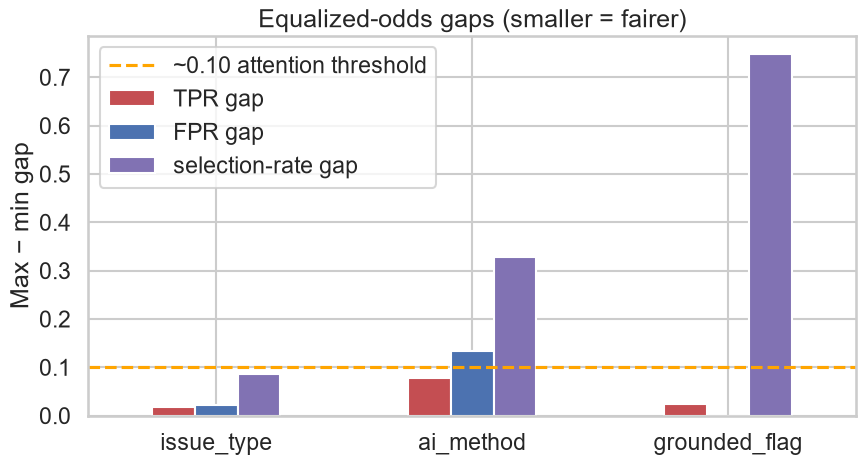

In [17]:
import numpy as np
# Plot 7: Equalized-odds gaps across three grouping variables
def eo_gaps(frame, col):
    rows = []
    for grp, sub in frame.groupby(col):
        yt    = sub["y_true"].values
        yp    = sub["y_pred"].values
        rec   = recall_score(yt, yp, zero_division=0) if (yt == 1).any() else np.nan
        fpr_g = (yp[yt == 0] == 1).mean() if (yt == 0).any() else np.nan
        sel   = yp.mean()
        rows.append({"group": grp, "recall": rec, "fpr": fpr_g, "sel": sel})
    g = pd.DataFrame(rows)
    return pd.Series({
        "TPR gap":            g["recall"].max() - g["recall"].min(),
        "FPR gap":            g["fpr"].max()    - g["fpr"].min(),
        "selection-rate gap": g["sel"].max()    - g["sel"].min(),
    })

summary = pd.DataFrame({
    "issue_type":    eo_gaps(fair, "issue_type"),
    "ai_method":     eo_gaps(fair, "ai_method"),
    "grounded_flag": eo_gaps(fair, "grounded_flag"),
}).T.round(3)

print("Equalized-odds gaps:\n", summary)

fig, ax = plt.subplots(figsize=(9, 5))
summary.plot(kind="bar", ax=ax, rot=0,
             color=["#C44E52", "#4C72B0", "#8172B3"])
ax.axhline(0.10, ls="--", color="orange", label="~0.10 attention threshold")
ax.set_title("Equalized-odds gaps (smaller = fairer)")
ax.set_ylabel("Max − min gap"); ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**
- issue_type gaps are small — the model treats Bug and Suggestion proposals
  with similar fairness. No action needed.
- ai_method shows the largest TPR and FPR gaps — this is the group where
  fairness attention is most needed, consistent with what Plot 6 showed.
- grounded_flag has a large selection-rate gap, which is expected by design:
  grounded proposals (real NFR violations) and synthetic proposals have
  structurally different flagging rates because they were generated differently.
  The TPR gap on grounded_flag is small, confirming the R4 check result above —
  the model catches real and synthetic violations at similar rates.

Overall: the model is procedurally fair on issue_type. The ai_method gap warrants
monitoring in Goal 3. The grounded_flag selection-rate gap is a known data
artifact, not a fairness failure.

This analysis directly addresses RAI-03 (Fairness) and Risk R8 from our heat-map.